### Mini Project: Analyze sales or temperature dataset to find patterns and correlations.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Aim: find patterns and correlations

Loading csv file and checking data

In [2]:
weather_data = r".\Weather Data in India from 1901 to 2017.csv"
df = pd.read_csv(weather_data)
print(f"Dataset loaded: {len(df)} {len(df.columns)} columns")

print("\nFirst few records:")

df.head()

Dataset loaded: 117 14 columns

First few records:


,Unnamed: 0,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,0,1901,17.99,19.43,23.49,26.41,28.28,28.60,27.49,26.98,26.26,25.08,21.73,18.95
1,1,1902,19.00,20.39,24.10,26.54,28.68,28.44,27.29,27.05,25.95,24.37,21.33,18.78
2,2,1903,18.32,19.79,22.46,26.03,27.93,28.41,28.04,26.63,26.34,24.57,20.96,18.29
3,3,1904,17.77,19.39,22.95,26.73,27.83,27.85,26.84,26.73,25.84,24.36,21.07,18.84
4,4,1905,17.40,17.79,21.78,24.84,28.32,28.69,27.67,27.47,26.29,26.16,22.07,18.71


checking data type and total columns , entries rows and columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  117 non-null    int64  
 1   YEAR        117 non-null    int64  
 2   JAN         117 non-null    float64
 3   FEB         117 non-null    float64
 4   MAR         117 non-null    float64
 5   APR         117 non-null    float64
 6   MAY         117 non-null    float64
 7   JUN         117 non-null    float64
 8   JUL         117 non-null    float64
 9   AUG         117 non-null    float64
 10  SEP         117 non-null    float64
 11  OCT         117 non-null    float64
 12  NOV         117 non-null    float64
 13  DEC         117 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 12.9 KB


checking unnessasary column name Unnamed 0 which is basically copy of index column


In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True, errors="ignore")

In [5]:
df.info()
df.describe()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YEAR    117 non-null    int64  
 1   JAN     117 non-null    float64
 2   FEB     117 non-null    float64
 3   MAR     117 non-null    float64
 4   APR     117 non-null    float64
 5   MAY     117 non-null    float64
 6   JUN     117 non-null    float64
 7   JUL     117 non-null    float64
 8   AUG     117 non-null    float64
 9   SEP     117 non-null    float64
 10  OCT     117 non-null    float64
 11  NOV     117 non-null    float64
 12  DEC     117 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 12.0 KB


YEAR    0
JAN     0
FEB     0
MAR     0
APR     0
MAY     0
JUN     0
JUL     0
AUG     0
SEP     0
OCT     0
NOV     0
DEC     0
dtype: int64

Reshaping dataframe using dataframe.melt 

In [6]:
df1 = df.melt(id_vars="YEAR", var_name="Month", value_name="Temperature_C")
df1.dropna(inplace=True)
print("Long format shape:", df1.shape)
print("Sample data:")
print(df1.head(10))

Long format shape: (1404, 3)
Sample data:
   YEAR Month  Temperature_C
0  1901   JAN          17.99
1  1902   JAN          19.00
2  1903   JAN          18.32
3  1904   JAN          17.77
4  1905   JAN          17.40
5  1906   JAN          17.50
6  1907   JAN          19.27
7  1908   JAN          18.35
8  1909   JAN          17.79
9  1910   JAN          18.14


In [7]:
df1.describe()

,YEAR,Temperature_C
count,1404.000000,1404.000000
mean,1959.000000,24.294160
std,33.785791,3.516446
min,1901.000000,17.250000
25%,1930.000000,21.067500
50%,1959.000000,25.570000
75%,1988.000000,27.240000
max,2017.000000,30.780000


1. Mean: μ = Σx/n
2. Standard Deviation: σ = √[Σ(x-μ)²/(n-1)]
3. Z-Score: z = (x - μ)/σ
4. Confidence Interval: μ ± z*(σ/√n)

In [8]:
mean_temp = df1["Temperature_C"].mean()
std_temp = df1["Temperature_C"].std()
n = len(df1)

standard_error = std_temp / np.sqrt(n)
z_val = 1.96  # i took this FOR 95% C.I

ci_low = mean_temp - z_val * standard_error
ci_high = mean_temp + z_val * standard_error

print(f"Mean Temperature: {mean_temp:.2f} °C")
print(f"95% Confidence Interval: ({ci_low:.2f}, {ci_high:.2f}) °C")

df1["Z_Score"] = (df1["Temperature_C"] - mean_temp) / std_temp

extreme_hot = sum(df1["Z_Score"] > 2)
extreme_cold = sum(df1["Z_Score"] < -2)

print(f"Extremely hot months (Z > 2): {extreme_hot}")
print(f"Extremely cold months (Z < -2): {extreme_cold}")

Mean Temperature: 24.29 °C
95% Confidence Interval: (24.11, 24.48) °C
Extremely hot months (Z > 2): 0
Extremely cold months (Z < -2): 1


T-TEST FORMULA: t = (x̄1 - x̄2) / √[(s1²/n1) + (s2²/n2)]

In [9]:
summer_months = ["APR", "MAY", "JUN", "JUL", "AUG", "SEP"]
winter_months = ["OCT", "NOV", "DEC", "JAN", "FEB", "MAR"]


summer_temps = df1[df1["Month"].isin(summer_months)]["Temperature_C"]
winter_temps = df1[df1["Month"].isin(winter_months)]["Temperature_C"]

from scipy import *

t_stat, p_val = stats.ttest_ind(summer_temps, winter_temps)

print(f"T-test Summer vs Winter:")
print(f"t-statistic = {t_stat:.2f}")
print(f"p-value = {p_val:.4f}")

T-test Summer vs Winter:
t-statistic = 62.44
p-value = 0.0000


 Pearson correlation coefficient  reference (r): 


In [13]:
month_order = [
    "JAN",
    "FEB",
    "MAR",
    "APR",
    "MAY",
    "JUN",
    "JUL",
    "AUG",
    "SEP",
    "OCT",
    "NOV",
    "DEC",
]
month_numbers = list(range(1, 13))
month_dct = {}

for i in range(len(month_order)):
    month_dct[month_order[i]] = month_numbers[i]

df1["Month_Num"] = df1["Month"].map(month_dct)
correlation_month = df1["Month_Num"].corr(df1["Temperature_C"])
correlation_year = df1["YEAR"].corr(df1["Temperature_C"])
print("Correlation between Month and Temperature:", round(correlation_month, 3))
print("Correlation between Year and Temperature:", round(correlation_year, 3))

Correlation between Month and Temperature: 0.089
Correlation between Year and Temperature: 0.081


In [14]:
x = df1["Month_Num"].values
y = df1["Temperature_C"].values
n = len(x)

# sums which is needed for formula
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x2 = np.sum(x**2)
sum_y2 = np.sum(y**2)
sum_xy = np.sum(x * y)

numerator = (n * sum_xy) - (sum_x * sum_y)
denominator = np.sqrt((n * sum_x2 - sum_x**2) * (n * sum_y2 - sum_y**2))
r = numerator / denominator

print(f"Pearson correlation coefficient (r): {r:.3f}")

Pearson correlation coefficient (r): 0.089


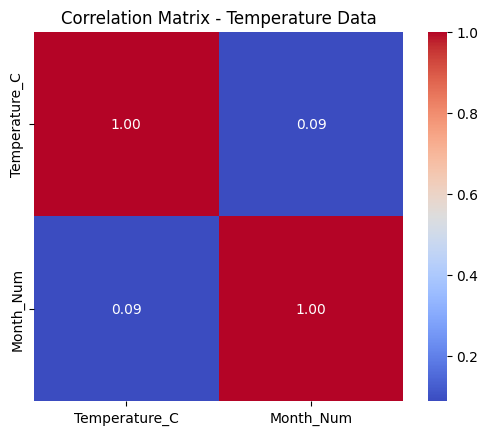

In [16]:
numeric_cols = ["Temperature_C", "Month_Num"]

corr_matrix = df1[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar=True)
plt.title("Correlation Matrix - Temperature Data")
plt.show()

Big -ve z_score = much colder than average.
Big +ve z_score = much hotter than average.
Z = Tem_c - mean / std

Z = Tem_c - mean / std

Temperature vs Month_Num ≈ 0.09

Z_Score vs Month_Num ≈ 0.09

For each year and month, I have the temperature, the month number, and a Z-score that shows how unusual that temperature is.

Temperature and Z-score were perfectly correlated (1.0) because Z-score is just temperature in standardized form.

Month number and temperature had a very small correlation (~0.09), meaning there is no simple straight-line relationship between month index (1–12) and temperature across all years.
The real pattern is seasonal: cold in winter, hot in summer, then cold again, which is a curve, not a line. 